<a href="https://colab.research.google.com/github/pamritha25/ML-and-DL-Projects/blob/main/E-Commerce/E_comerceRevenue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **E-commerce revenue**

**Problem statement**

In the modern digital economy, organizations rely heavily on data-driven strategies to improve business performance and increase profitability. Various operational factors such as marketing expenditure, website traffic, customer conversion rates, discount strategies, customer retention levels, and seasonal trends can significantly influence a company’s monthly revenue. However, determining how these factors interact and contribute to revenue generation is a complex analytical task.

The objective of this project is to build an accurate regression-based predictive model using a dataset containing 75,000 records. The model will analyze key business performance indicators and estimate monthly revenue based on these variables. Through systematic data preprocessing, exploratory data analysis, and the application of Machine Learning and Deep Learning regression algorithms, the study aims to uncover the most impactful factors affecting revenue and improve the reliability of revenue forecasting for business decision-making.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/ecommerce_revenue_75000 (1).csv")
df.head()

,marketing_spend,website_traffic,conversion_rate,avg_order_value,returning_customer_rate,discount_rate,seasonality_index,monthly_revenue
0,57450.71,106117.00,0.0766,79.74,0.1480,0.1516,0.806,526876.14
1,47926.04,102040.88,0.1235,71.71,0.4763,0.1884,1.164,1058314.50
2,59715.33,108142.06,0.1054,96.76,0.1077,0.0161,0.816,920127.08
3,72845.45,157265.40,0.0602,114.26,0.3477,0.3577,1.061,1172824.41
4,46487.70,85497.27,0.0164,47.93,0.4870,0.0055,1.069,95596.68


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   marketing_spend          75000 non-null  float64
 1   website_traffic          75000 non-null  float64
 2   conversion_rate          75000 non-null  float64
 3   avg_order_value          75000 non-null  float64
 4   returning_customer_rate  75000 non-null  float64
 5   discount_rate            75000 non-null  float64
 6   seasonality_index        75000 non-null  float64
 7   monthly_revenue          75000 non-null  float64
dtypes: float64(8)
memory usage: 4.6 MB


In [ ]:
df.isnull().sum()

,0
marketing_spend,0
website_traffic,0
conversion_rate,0
avg_order_value,0
returning_customer_rate,0
discount_rate,0
seasonality_index,0
monthly_revenue,0


In [ ]:
df.duplicated().sum()

np.int64(0)

**visualization**

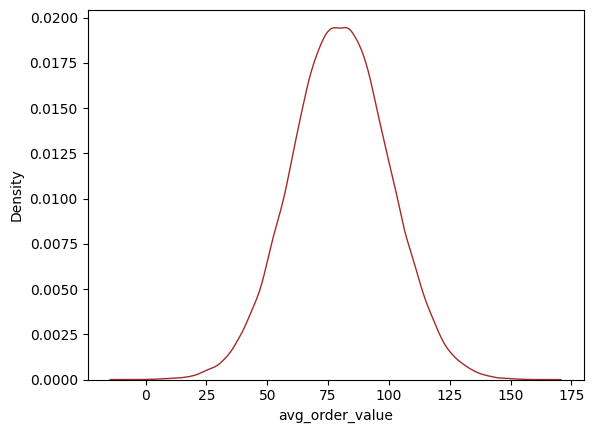

In [ ]:
sns.kdeplot(x=df["avg_order_value"], color="brown", linewidth=1)

plt.show()

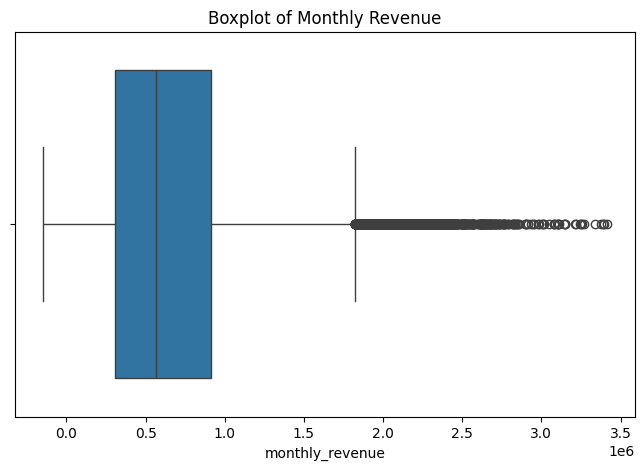

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["monthly_revenue"])
plt.title("Boxplot of Monthly Revenue")
plt.show()

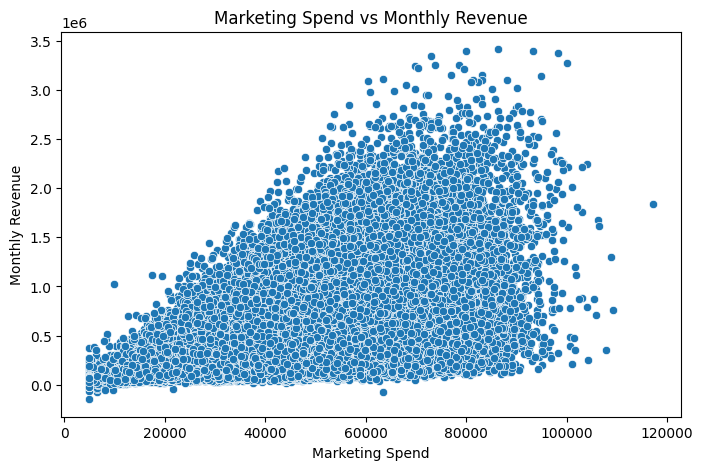

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["marketing_spend"], y=df["monthly_revenue"])
plt.title("Marketing Spend vs Monthly Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Monthly Revenue")
plt.show()

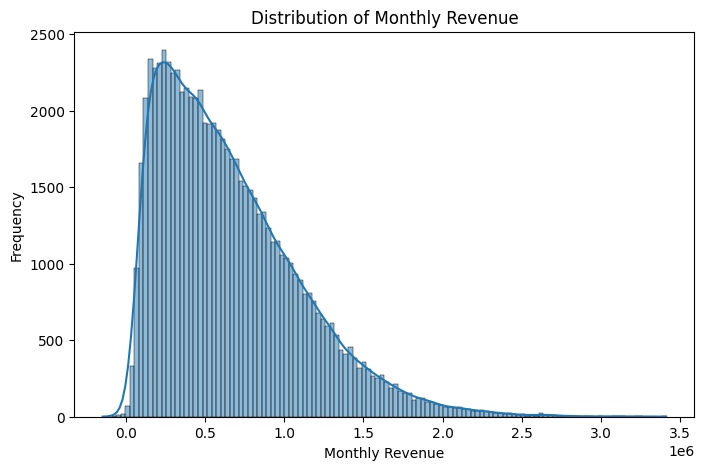

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["monthly_revenue"], kde=True)
plt.title("Distribution of Monthly Revenue")
plt.xlabel("Monthly Revenue")
plt.ylabel("Frequency")
plt.show()

# **Correlation**

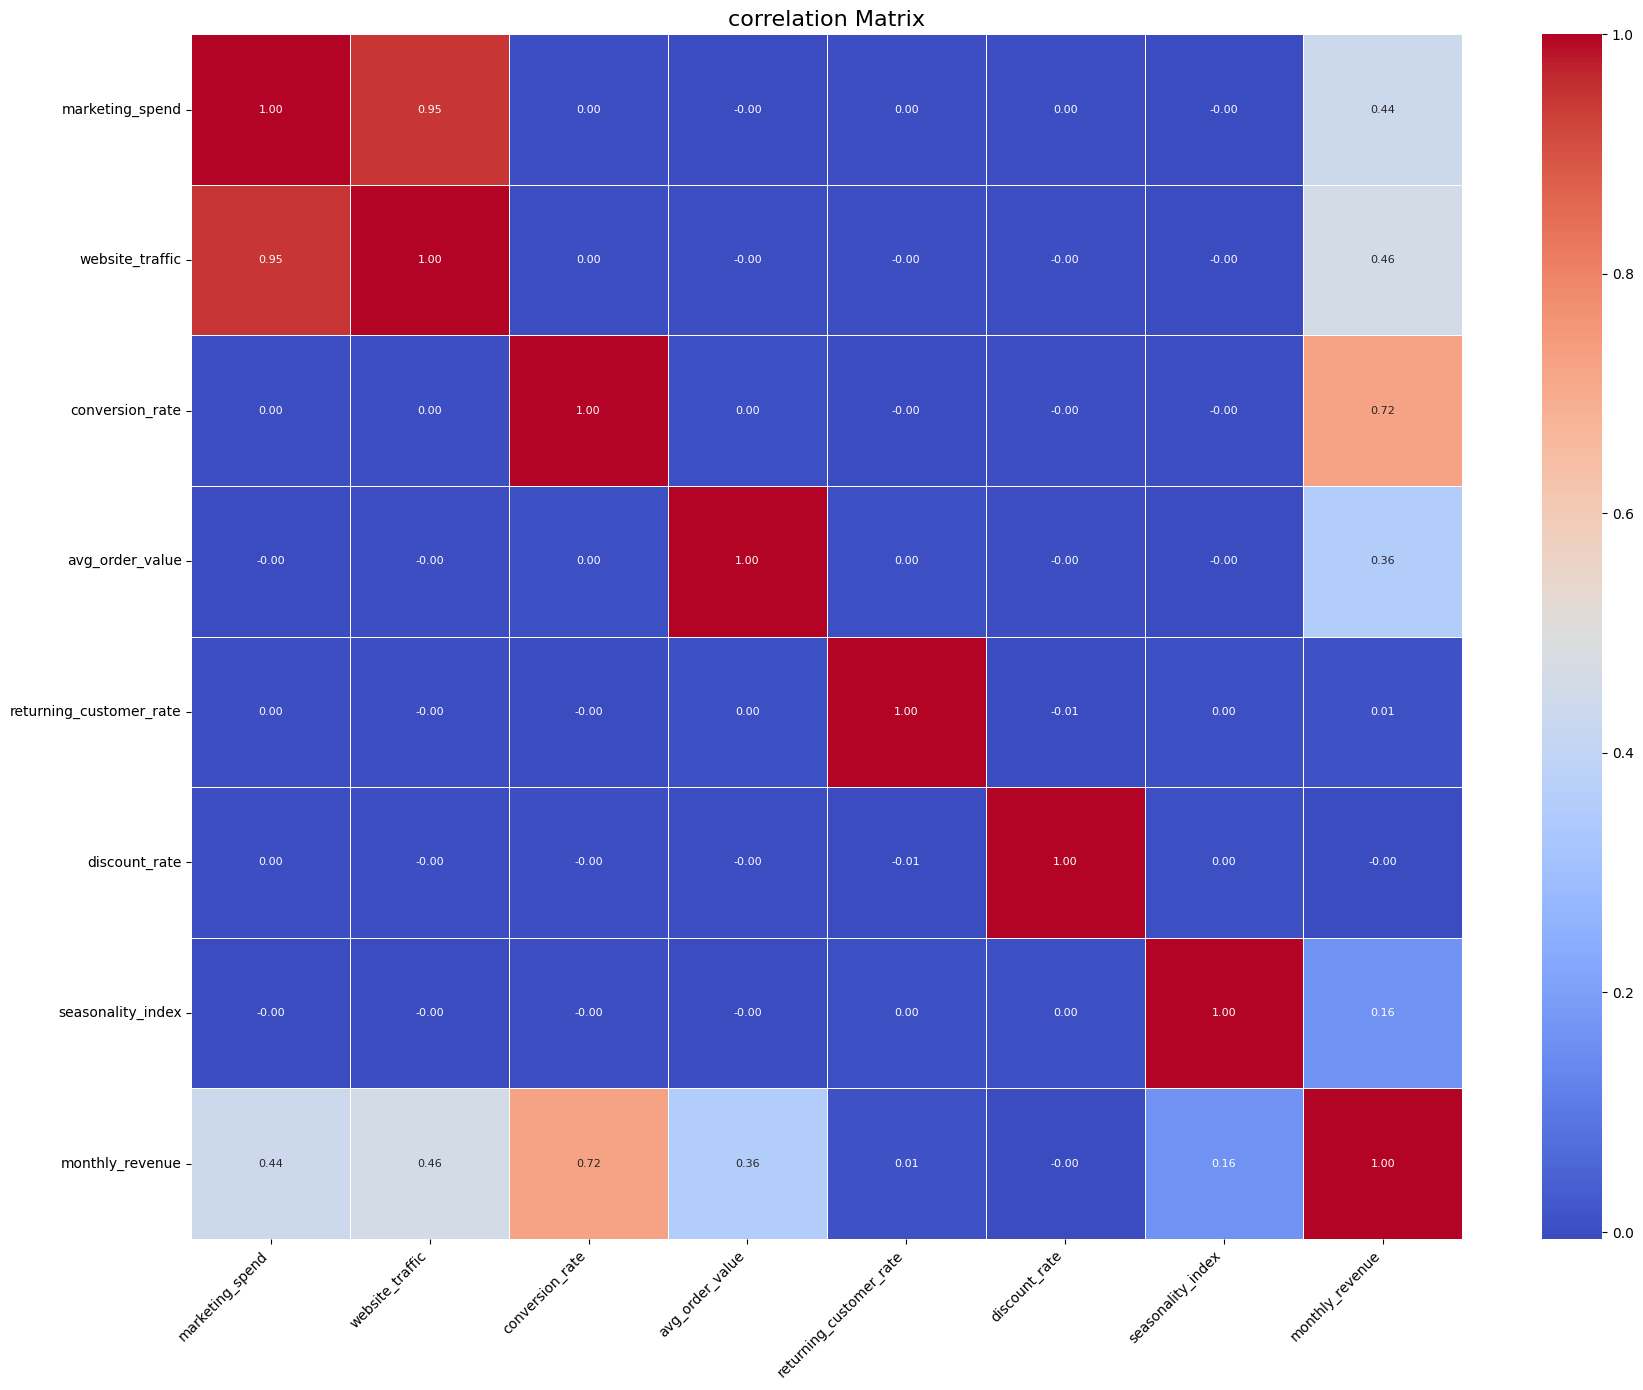

In [ ]:
plt.figure(figsize=(18,14))
corr_matrix=df.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,annot_kws={"size":8})
plt.title("correlation Matrix",fontsize=16)
plt.xticks(rotation=45,ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

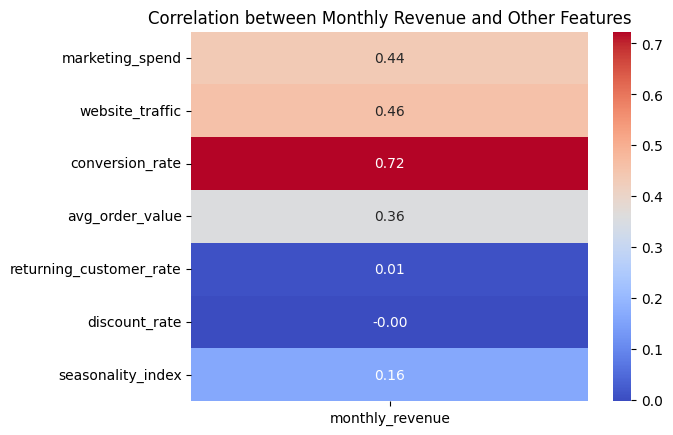

In [ ]:
monthly_revenue_corr = df.corr()['monthly_revenue']

monthly_revenue_corr = monthly_revenue_corr.drop('monthly_revenue')

sns.heatmap(monthly_revenue_corr.to_frame(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar=True,
            annot_kws={'size':10})

plt.title('Correlation between Monthly Revenue and Other Features')
plt.show()

In [ ]:
df.drop(["discount_rate","returning_customer_rate"], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   marketing_spend    75000 non-null  float64
 1   website_traffic    75000 non-null  float64
 2   conversion_rate    75000 non-null  float64
 3   avg_order_value    75000 non-null  float64
 4   seasonality_index  75000 non-null  float64
 5   monthly_revenue    75000 non-null  float64
dtypes: float64(6)
memory usage: 3.4 MB


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



features = ["monthly_revenue","seasonality_index","avg_order_value","conversion_rate","website_traffic","marketing_spend"]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

<Axes: >

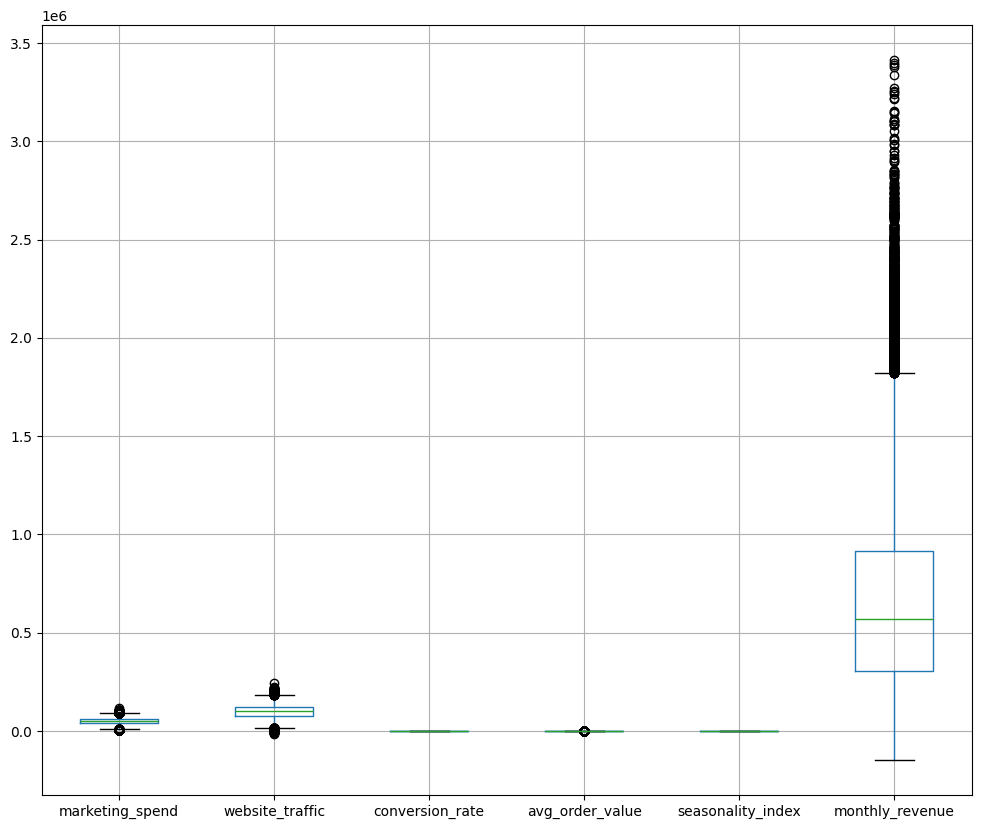

In [ ]:
plt.figure(figsize=(12,10))
df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:

        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df


df_cleaned = remove_outliers_iqr(df, exclude_column='monthly_revenue')
df=df_cleaned

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd



X = df[["marketing_spend","website_traffic","conversion_rate","avg_order_value","seasonality_index",]]
y = df["monthly_revenue"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)




model =LinearRegression ()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
model.score(X_test,y_test)

0.8922994657987182

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
model.score(X_test,y_test)

0.9855275197038063

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR


X = df[["marketing_spend","website_traffic","conversion_rate","avg_order_value","seasonality_index"]]
y = df["monthly_revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model=SVR()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
model.score(X_test,y_test)


-0.03264830748333214

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

import pandas as pd

X= df[["marketing_spend","website_traffic","conversion_rate","avg_order_value","seasonality_index"]]
y = df["monthly_revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
model.score(X_test,y_test)

0.9970327246291913

# **DL**

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
best_X_train,best_X_test,best_y_train,best_y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=42)

In [ ]:
model=Sequential()
model.add(Dense(256,input_shape=(5,),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))
model.compile(loss='mse',optimizer='adam',metrics=['mae'])
model.fit(best_X_train,best_y_train,epochs=100,batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 245711945728.0000 - mae: 315956.0625
Epoch 2/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8502589952.0000 - mae: 67706.5312
Epoch 3/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 6595681280.0000 - mae: 59149.6641
Epoch 4/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 5156095488.0000 - mae: 51794.5898
Epoch 5/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2726370816.0000 - mae: 35629.1016
Epoch 6/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1833900288.0000 - mae: 29045.1895
Epoch 7/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1526466816.0000 - mae: 25918.7715
Epoch 8/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 971123392.0000 - mae: 20922.6797
Epoch 9/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 655788096.0000 - mae: 17797.6543
Epoch 10/100
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 530652800.0000 - mae: 16417.6504
Epoch 11/100
1613/1613 ━━━━━

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

import pandas as pd

X= df[["marketing_spend","website_traffic","conversion_rate","avg_order_value","seasonality_index"]]
y = df["monthly_revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
model.score(X_test,y_test)

0.9969714199149389

In [ ]:
import pickle
with open("revenue e commerce model.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/revenue e commerce model.pkl","rb") as file:
  load_model=pickle.load(file)

# **Conclusion**

In this project, a robust Monthly Revenue Prediction System was developed using a dataset of 75,000 business records. After performing data preprocessing, feature scaling, and exploratory data analysis, multiple regression algorithms were implemented and compared.

Among all the models, Random Forest Regressor delivered the highest accuracy and best overall performance, effectively capturing complex non-linear relationships between marketing metrics and monthly revenue. Key influencing factors identified through feature importance analysis included conversion rate, average order value, marketing spend, and returning customer rate.

To make the model production-ready, the best-performing Random Forest model was serialized and saved in pickle format, enabling easy deployment and integration into real-world applications such as business dashboards or web-based revenue forecasting systems.

Overall, this project demonstrates how machine learning can transform business performance metrics into accurate revenue forecasts, supporting strategic decision-making, marketing budget optimization, and profitability growth.